# Eval LLama-2 chat model

* So far I just have a single run on record
* Implement a bit of a 'automatic grab from wandb thing'
* Try out bootstrapped uncertainty estimates
* See if old/new semantic uncertainy metrics still all perform about the same

In [2]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


import wandb
api = wandb.Api()
api.entity = 'goatml'

In [55]:
# export to eval file
def get_vals(x):
    return x['mean'], x['bootstrap']['low'], x['bootstrap']['high']

def get_perfs(metrics):
    data = []
    for method in metrics['performance']:
        mean, low, high = get_vals(metrics['performance'][method])
        data.append([method, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'means', 'low', 'high'])
    return df.set_index('method')

def plot_bar(df, color='C0'):
    df.plot.bar(y='means', yerr=[df.means - df.low, df.high - df.means], color=color)

def get_uncertainty_df(metrics):
    data = []
    for method in metrics['uncertainty']:
        for metric in metrics['uncertainty'][method]:
            mean, low, high = get_vals(metrics['uncertainty'][method][metric])
            data.append([method, metric, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'metric', 'means', 'low', 'high'])
    
    df = df.set_index('method')

    def get_base_method(x):
        if 'p_false' in x:
            return 'p_false'
        elif 'p_ik' in x:
            return 'p_ik'
        elif 'regular_entropy' in x:
            return 'regular_entropy'
        elif 'cluster_assignment' in x:
            return x
        elif 'semantic_entropy' in x:
            return 'semantic_entropy'
        else:
            raise
    df['base_method'] = df.index.map(get_base_method)
    return df

def plot_bar_uncertainty(pdf, metric, remove='_UNANSWERABLE'):
    tmp = pdf
    # filter out unanswerable
    if remove is not None:
        tmp = tmp[tmp.index.map(lambda x: remove not in x)]
    tmp = tmp.reset_index()
    tmp = tmp.set_index('metric').loc[metric]
    tmp = tmp.set_index('method')
    tmp = tmp.sort_values('base_method')

    b2c = {m:f'C{i}' for i, m in enumerate(tmp.base_method.unique())}
    basemethod2color = lambda x: b2c[x]

    plot_bar(tmp, color=tmp.base_method.map(basemethod2color))
    plt.gca().grid(axis='y', zorder=-10, alpha=0.3)
    plt.title(metric)




In [40]:
def restore_file(wandb_id, filenames=['wandb-summary.json', 'config.yaml']):
    files_dir = 'notebooks/restored_files'    
    os.system(f'mkdir -p {files_dir}')

    run = api.run(f'goatml/semantic_uncertainty/{wandb_id}')
    # run = api.run(f'goatml/uncertainty/{wandb_id}')
    out = []

    for filename in filenames:
        
        path = f'{files_dir}/{filename}'
        os.system(f'rm -rf {path}')
        run.file(filename).download(root=files_dir, replace=True, exist_ok=False)
    
        if filename.endswith('.pkl'):
            with open(path, 'rb') as f:
                out.append(pickle.load(f))
        elif filename.endswith('.yaml'):
            with open(path, 'r') as f:
                out.append(yaml.safe_load(f))
        elif filename.endswith('.json'):
            with open(path, 'r') as f:
                out.append(json.load(f))
        else:
            raise

    return out

In [68]:
# wandb_ids = ['blrpdl7m']
wandb_ids = ['z4pho3db']
# --> will automate in the future --> this is for record?!!
# https://wandb.ai/goatml/uncertainty/runs/up7kvqqr/overview?workspace=user-jlko
# runtime was 1 hour --> 5 times faster than llama-65B run (but was at num_fewshot = 1 to avoid OOM). and 18 times faster than falcon-40B run!

all_configs, all_results = {}, {}

for wandb_id in wandb_ids:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)
    break
config = all_configs[wandb_id]
results = all_results[wandb_id]

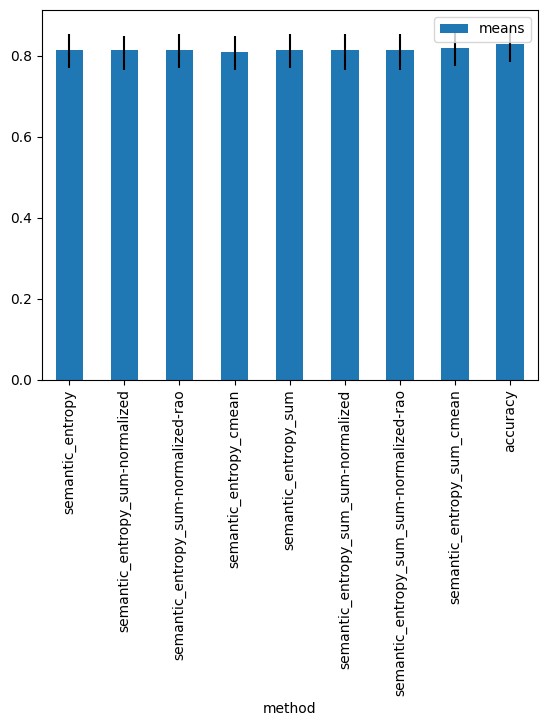

In [62]:
df = get_perfs(results)
plot_bar(df)

In [65]:
pdf = get_uncertainty_df(results)
metric_names = pdf.metric.unique()
metric_names

array(['AUROC', 'area_under_thresholded_accuracy', 'mean_uncertainty',
       'accuracy_at_0.8_answer_fraction',
       'accuracy_at_0.9_answer_fraction',
       'accuracy_at_0.95_answer_fraction'], dtype=object)

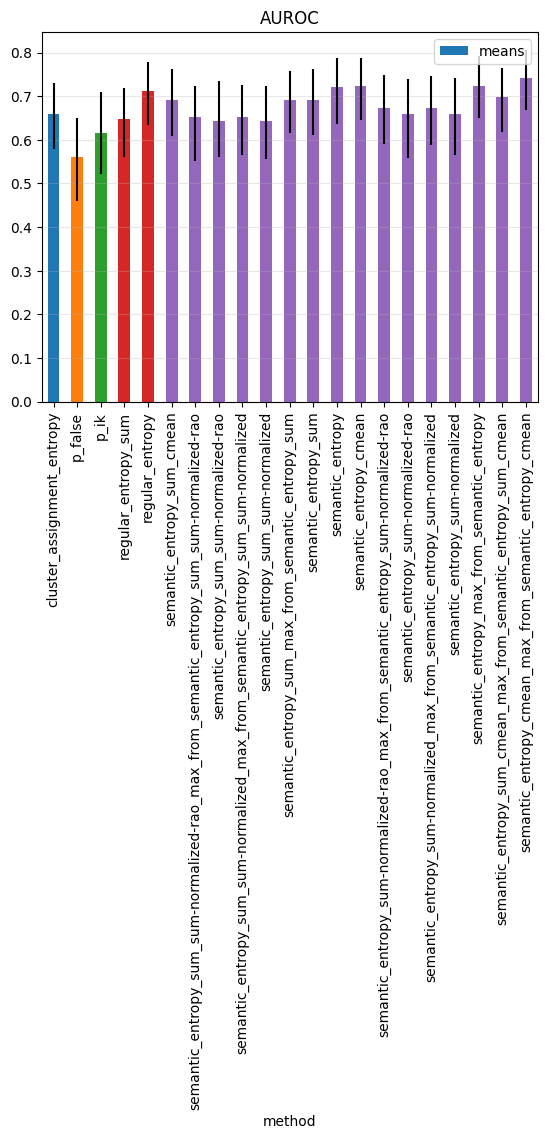

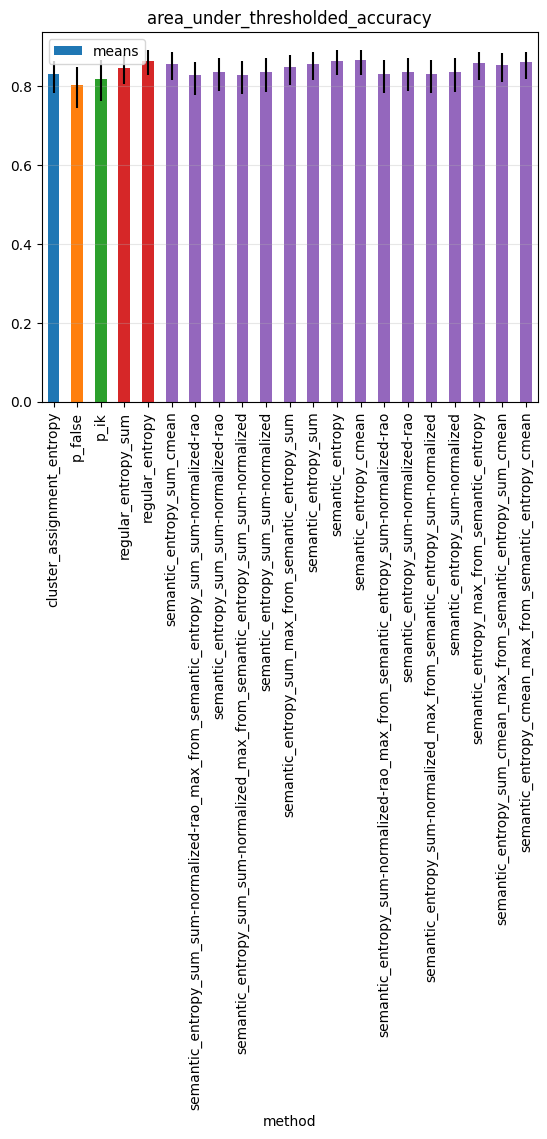

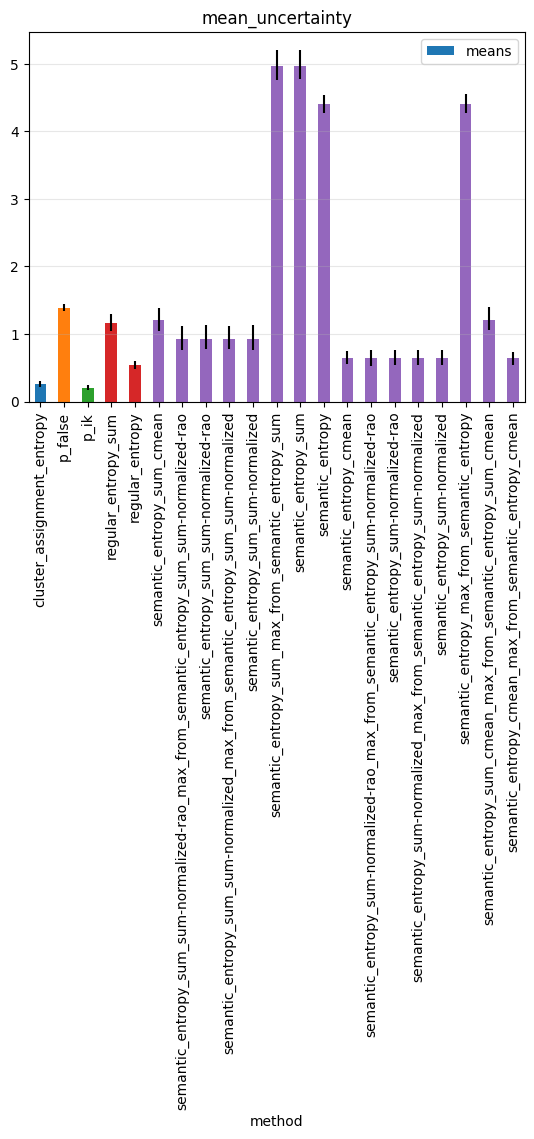

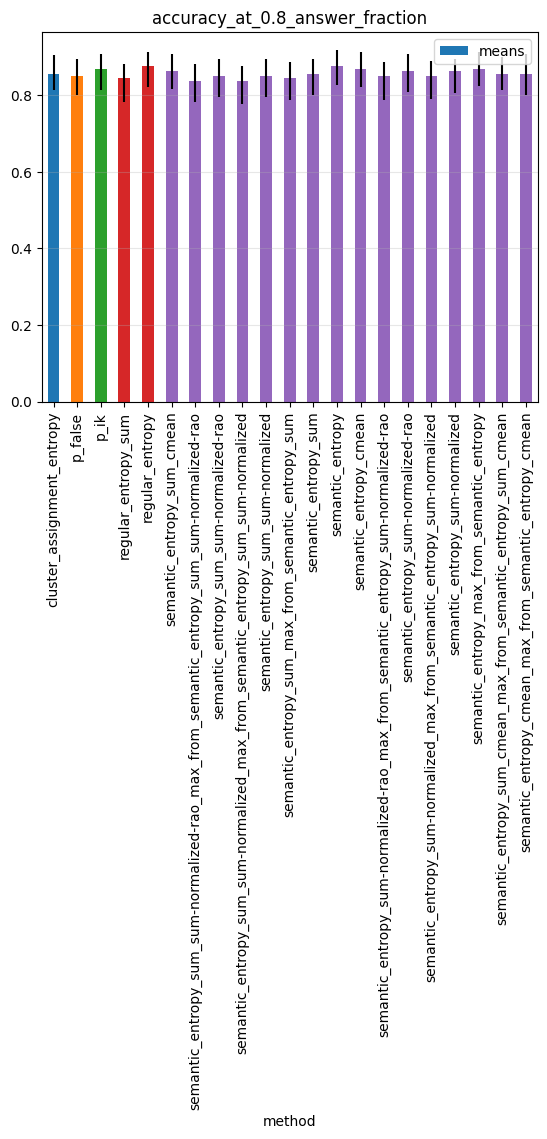

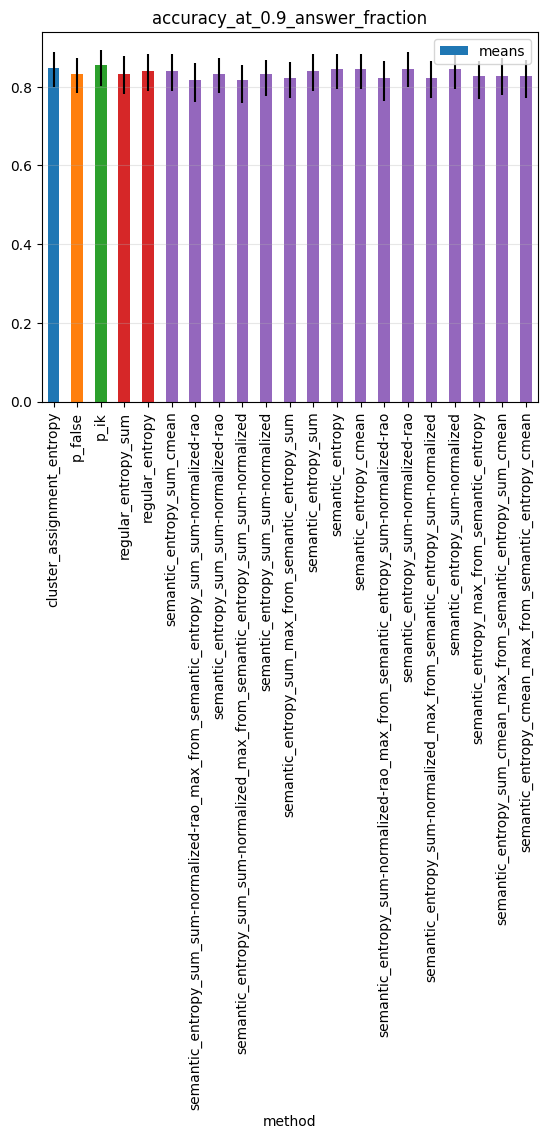

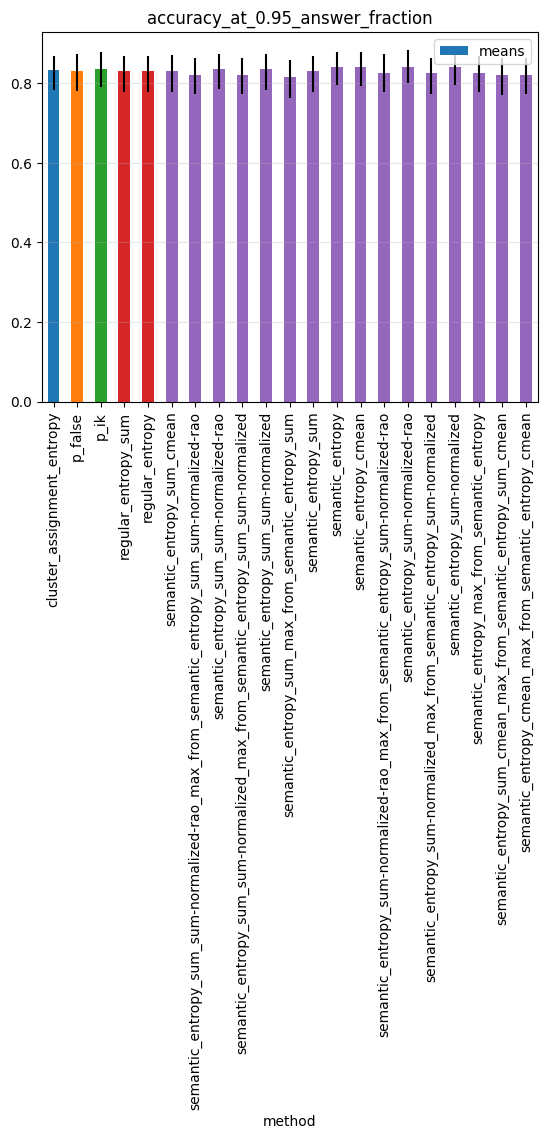

In [67]:
for name in list(metric_names):
    plot_bar_uncertainty(pdf, name)